# Insurance Cost Forecasting Model

## Import libs

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Import Datasets

In [2]:
# Loading Datasets
df = pd.read_csv("datasets/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Get Data Insights

- Data Structure
- Correlations (HeatMaps)
- Time-series
- 

### Data Structures

In [3]:
# Get gender count
males = (df["sex"] == "male").sum()
females = (df["sex"] == "female").sum()
gender = [males, females]

# Get smoker
smokers = (df["smoker"] == "yes").sum()
non_smokers = (df["smoker"] == "no").sum()
is_smoking = [smokers, non_smokers]

# Get number of children per person
children_counts = df["children"].value_counts().sort_index()
children_labels = children_counts.index.astype(str)
children_sizes = children_counts.values

# Get region count
region_counts = df["region"].value_counts().sort_index()
region_labels = region_counts.index.astype(str)
region_sizes = region_counts.values

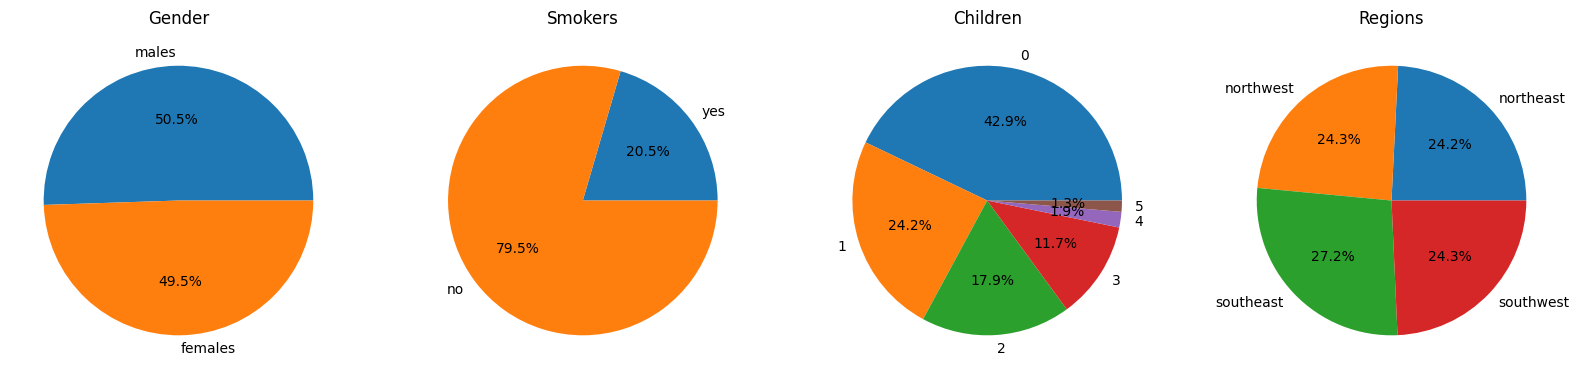

In [4]:
fig, ax = plt.subplots(1, 4, figsize=(20, 5))

ax[0].pie(gender, labels=["males", "females"], autopct='%1.1f%%')
ax[0].set_title("Gender")

ax[1].pie(is_smoking, labels=["yes", "no"], autopct='%1.1f%%')
ax[1].set_title("Smokers")

ax[2].pie(children_sizes, labels=children_labels, autopct='%1.1f%%')
ax[2].set_title("Children")

ax[3].pie(region_sizes, labels=region_labels, autopct="%1.1f%%")
ax[3].set_title("Regions")

plt.show()

## Data Pre-processing

To get more insights on data like #correlation and #Heatmaps , we need to transform data into numerical values. 

Our dataset contains text-data ( #categorical-data ) which can be converted into numeric data using #feature-encoding 

To learn more on #feature-encoding refer to [[Feature Encoding]]

As our dataset includes some #categorical-data -> sex, smoker, region. So we apply encoding techniques to transform these #features 

- sex -> #binary-encoding 
- smoker -> #binary-encoding 
- region -> #one-hot-encoding 

The region feature is divided into four categories, that's why it must be encoded with #one-hot-encoding to prevent priority to higher encoded category.

### Binary Encoding
This encoding is applied on Sex, Smoker feature

In [5]:
# Binary Encoding applied on sex, smaker

df["sex"] = df["sex"].map({"female": 0, "male": 1}).astype(bool)
df["smoker"] = df["smoker"].map({"no": 0, "yes": 1}).astype(bool)

df[["sex", "smoker"]].head()

,sex,smoker
0,False,True
1,True,False
2,True,False
3,True,False
4,True,False


### One-Hot Encoding
This encoding is applied on region feature

In [6]:
df["region"].nunique()

4

In [7]:
# OHE applied on regions

df = pd.get_dummies(df, columns=["region"])
df.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,False,27.900,0,True,16884.92400,False,False,False,True
1,18,True,33.770,1,False,1725.55230,False,False,True,False
2,28,True,33.000,3,False,4449.46200,False,False,True,False
3,33,True,22.705,0,False,21984.47061,False,True,False,False
4,32,True,28.880,0,False,3866.85520,False,True,False,False


### Correlations

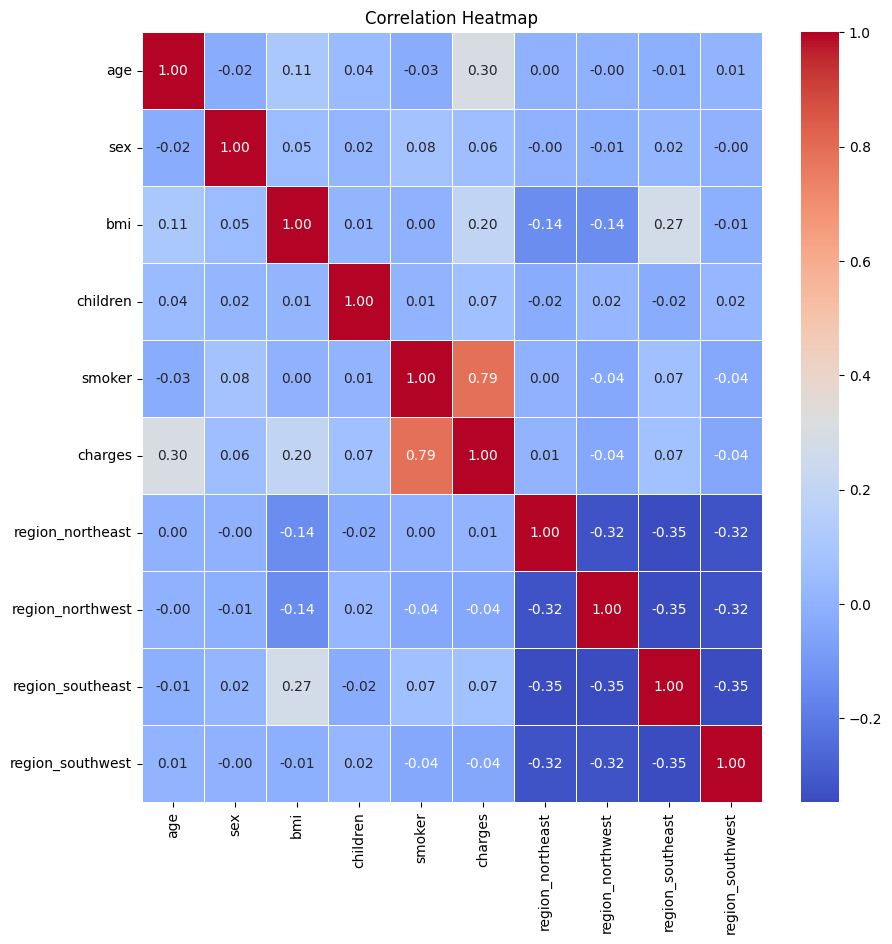

In [8]:
# Calculate and display correlation matrix
corr = df.corr()

plt.figure(figsize=(10, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()